# Smart Reorder System (Forecast-Driven)

## Purpose

This notebook implements the operational decision-making layer of the  
**Smart Inventory Management System**.

Using ARIMA-based demand forecasts and historical demand variability,  
the system computes:

- Lead Time Demand  
- Safety Stock  
- Reorder Point (ROP)  
- Forecast Cycle Demand  
- Dynamic Order Quantity  
- Product-Level Risk Classification  
- Warehouse-Level KPIs  

This connects forecasting output to inventory control decisions.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

import sys
import os

sys.path.append(os.path.abspath("../src"))

from reorder_logic import (
    compute_reorder_table,
    compute_warehouse_summary
)

## Load Forecast Results

These values were generated by the ARIMA forecasting engine  
(`02_forecasting.ipynb`) and represent expected future demand.

In [ ]:
forecast_df = pd.read_csv("../outputs/tables/forecast_results.csv")
forecast_df.head()

,Date,Product Name,ARIMA
0,2017-04-22,Bridgestone e6 Straight Distance NFL San Dieg,0.248575
1,2017-04-23,Bridgestone e6 Straight Distance NFL San Dieg,0.476748
2,2017-04-24,Bridgestone e6 Straight Distance NFL San Dieg,0.462870
3,2017-04-25,Bridgestone e6 Straight Distance NFL San Dieg,0.463714
4,2017-04-26,Bridgestone e6 Straight Distance NFL San Dieg,0.463663


## Load Historical Demand Data

Historical variability determines Safety Stock.

In [ ]:
historical_df = pd.read_csv("../data/processed/daily_demand.csv")
historical_df.head()

,order date (DateOrders),Product Name,Order Item Quantity
0,2015-01-01,Bridgestone e6 Straight Distance NFL San Dieg,3
1,2015-01-01,Diamondback Women's Serene Classic Comfort Bi,10
2,2015-01-01,Field & Stream Sportsman 16 Gun Fire Safe,7
3,2015-01-01,Glove It Imperial Golf Towel,5
4,2015-01-01,Glove It Urban Brick Golf Towel,5


## Business Assumptions

- Lead Time = 7 days  
- Service Level = 95%  
- Forecast Horizon = 14 days  

Z-score is automatically computed based on service level.

In [ ]:
lead_time = 7
service_level = 0.95
forecast_horizon = 14

z_value = norm.ppf(service_level)

## Multi-Product Reorder Engine

The following function evaluates all products and computes:

- Lead Time Demand  
- Safety Stock  
- Reorder Point  
- Forecast Cycle Demand  
- Order Quantity  
- Final Recommendation  
- Risk Level  

Logic is modularized inside:

`src/reorder_logic.py`

In [ ]:
reorder_table = compute_reorder_table(
    forecast_df,
    historical_df,
    lead_time=lead_time,
    service_level=service_level,
    forecast_horizon=forecast_horizon
)

reorder_table.head()

,Product,Lead Time Demand,Safety Stock,Reorder Point,Forecast Cycle Demand (14d),Current Stock,Order Quantity,Status,Risk Level
0,Summer dresses,220.0,39.0,259.0,439.0,151,327,Reorder,🔴 High Risk
1,Nike Men's Dri-FIT Victory Golf Polo,193.0,49.0,242.0,387.0,134,302,Reorder,🔴 High Risk
2,Perfect Fitness Perfect Rip Deck,224.0,51.0,275.0,448.0,216,283,Reorder,🔴 High Risk
3,Rock music,163.0,55.0,218.0,326.0,155,226,Reorder,🔴 High Risk
4,Industrial consumer electronics,146.0,39.0,185.0,292.0,120,211,Reorder,🔴 High Risk


C:\Users\jenis\AppData\Local\Temp\ipykernel_9792\4134901336.py:22: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("../outputs/figures/reorder_table.png", bbox_inches='tight')
C:\Users\jenis\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


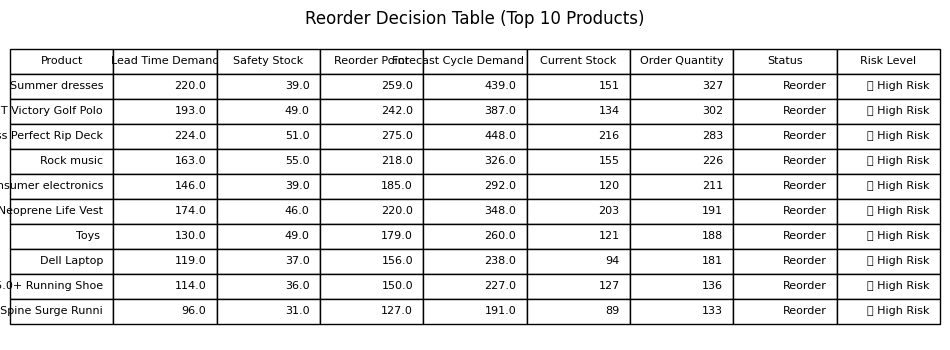

In [ ]:
# Reorder Table Image (Top 10 Products)

import matplotlib.pyplot as plt

display_df = reorder_table.head(10)

plt.figure(figsize=(12,4))
plt.axis('off')

table = plt.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

plt.title("Reorder Decision Table (Top 10 Products)")

plt.savefig("../outputs/figures/reorder_table.png", bbox_inches='tight')

plt.show()

In [ ]:
print("Total Products:", len(reorder_table))
print("Products Needing Reorder:", (reorder_table["Status"] == "Reorder").sum())

reorder_table.sample(5)

Total Products: 105
Products Needing Reorder: 104


,Product,Lead Time Demand,Safety Stock,Reorder Point,Forecast Cycle Demand (14d),Current Stock,Order Quantity,Status,Risk Level
78,Nike Kids' Grade School KD VI Basketball Shoe,4.0,8.0,12.0,7.0,4,11,Reorder,🔴 High Risk
40,Glove It Women's Mod Oval 3-Zip Carry All Gol,3.0,8.0,11.0,6.0,1,13,Reorder,🔴 High Risk
70,Nike Women's Tempo Shorts,4.0,8.0,12.0,7.0,4,11,Reorder,🔴 High Risk
100,Merrell Women's Grassbow Sport Waterproof Hik,2.0,2.0,4.0,3.0,1,4,Reorder,🔴 High Risk
50,Glove It Imperial Golf Towel,4.0,8.0,12.0,8.0,4,12,Reorder,🔴 High Risk


## Warehouse-Level Summary

High-level metrics used in the Streamlit dashboard.

In [ ]:
summary_df = compute_warehouse_summary(reorder_table)
summary_df

,Total Products,Products Needing Reorder,Total Order Quantity,Reorder Rate (%)
0,105,104,4353,99.05


## Export Outputs

These CSV files feed directly into the Streamlit Inventory Dashboard:

- `reorder_summary.csv`  
- `warehouse_summary.csv`  

In [ ]:
reorder_table.to_csv("../outputs/tables/reorder_summary.csv", index=False)
summary_df.to_csv("../outputs/tables/warehouse_summary.csv", index=False)